# TAHAP 3 — Kalibrasi Diagnostik Subsistem Wisatawan (P5)

**Tidak ada nilai yang diadopsi.** Tahap ini hanya mengukur berapa besar perubahan LPE yang
dituntut data, dan apakah parameternya teridentifikasi.

**File:** `Uji_Parsial_P5.mdl` versi v3 (Laju Konversi Dasar 0,0638662 hasil Tahap 2).
**Target:** Jumlah Wisatawan, dibandingkan dengan seri sambungan (faktor 2,2997).

| Varian | Periode / perlakuan | Tujuan |
|---|---|---|
| **D-A (utama)** | 2016–2019 (periode normal) | LPE yang dituntut data tanpa pengaruh pemulihan |
| **D-B** | 2016–2019 + 2022–2025 | mengukur tuntutan rezim pemulihan |
| **D-C** | D-A dengan faktor sambung 2,22 dan 2,38 | kepekaan terhadap penyambungan |
| **D-D** | grid 2D LPE × rasio LPD/LPE 0,60–0,90 | **uji keteridentifikasian** |

Nilai final LPE/LPD tetap 0,27726 / 0,207945 kecuali kelima kriteria penerimaan terpenuhi:
dasar empiris, dasar struktural, keteridentifikasian, kekokohan, dan kewajaran proyeksi.

In [1]:
!pip install pysd openpyxl matplotlib scipy -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.1/95.1 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 717.0/717.0 kB 26.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150.2/150.2 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.4/54.4 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 919.5/919.5 kB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.4/268.4 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 7.3 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import warnings
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt, pysd
from scipy import stats
warnings.filterwarnings("ignore")

FOLDER = Path("/content/drive/MyDrive/Skripsi_Citra/Pengujian Model Sistem Dinamis/[02] Uji Perilaku/Kalibrasi")
FILE = FOLDER / "Uji Parsial P5 V3.mdl"

TAHUN = np.arange(2016, 2026)
JW_ASLI = np.array([6551294,6644412,7996959,20520104,19610135,22849394.5,
                    25755726,30542580,38134536,40695654], float)   # data BPS apa adanya

def sambung(faktor):
    """Seri sambungan: 2016-2018 (metode lama) dikalikan faktor penyambung."""
    d = JW_ASLI.copy(); d[:3] = d[:3]*faktor; return d

DATA = sambung(2.2997)
DA = np.array([2016,2017,2018,2019])                       # periode normal
DB = np.array([2016,2017,2018,2019,2022,2023,2024,2025])   # + pemulihan
M_DA, M_DB = np.isin(TAHUN, DA), np.isin(TAHUN, DB)
NONCOVID = ~np.isin(TAHUN, [2020,2021])
LPE0, RASIO = 0.27726, 0.75

In [5]:
def nrmse(sim, act, msk):
    return np.sqrt(np.mean((sim[msk]-act[msk])**2)) / act[msk].mean()

def statistik(sim, act, t):
    e = sim-act; SA, SS, SE = act.std(), sim.std(), e.std()
    r = np.corrcoef(sim, act)[0,1]; mse = np.mean(e**2)
    la, ls = stats.linregress(t, act), stats.linregress(t, sim); n = len(t)
    th = abs(ls.slope-la.slope)/np.sqrt(la.stderr**2+ls.stderr**2); tt = stats.t.ppf(0.975, 2*n-4)
    tren = ("Berlawanan arah" if np.sign(ls.slope) != np.sign(la.slope)
            else ("Berbeda nyata" if th > tt else "Tidak berbeda nyata"))
    return {"Tren":tren, "E1":abs(sim.mean()-act.mean())/abs(act.mean()), "E2":abs(SS-SA)/SA,
            "DC":SE/(SA+SS), "U1":(sim.mean()-act.mean())**2/mse, "U2":(SS-SA)**2/mse,
            "U3":2*(1-r)*SS*SA/mse}

model = pysd.read_vensim(str(FILE))

def run(lpe, rasio=RASIO):
    """LPD selalu mengikuti rasio; rasio 0,75 adalah asumsi struktural."""
    r = model.run(params={"Laju Pertumbuhan Eksternal":lpe, "Laju Penurunan Dasar":rasio*lpe},
                  return_columns=["Jumlah Wisatawan"], return_timestamps=list(TAHUN))
    return np.real(r["Jumlah Wisatawan"].values.astype(complex))

h0 = run(LPE0)
print(f"Cek: JW 2017 = {h0[1]:,.0f} (harus 16.035.938) | JW 2025 = {h0[-1]:,.0f}")

Cek: JW 2017 = 16,035,938 (harus 16.035.938) | JW 2025 = 26,512,893


## D-A, D-B, D-C — profil J terhadap LPE

In [6]:
LPE = np.round(np.arange(0.10, 0.80001, 0.005), 4)
cache = {float(l): run(float(l)) for l in LPE}

ring = []
for nama, msk in [("D-A (2016-2019)", M_DA), ("D-B (2016-2019 + 2022-2025)", M_DB)]:
    j = np.array([nrmse(cache[float(l)], DATA, msk) for l in LPE]); i = int(j.argmin())
    I = LPE[j <= 1.05*j[i]]; jt = nrmse(h0, DATA, msk)
    ring.append({"Varian":nama, "LPE*":LPE[i], "g* (%/th)":100*0.25*LPE[i], "J min":j[i], "J turunan":jt,
                 "Perbaikan (%)":100*(jt-j[i])/jt, "I bawah":I[0], "I atas":I[-1],
                 "Turunan dalam I":bool(jt <= 1.05*j[i])})

for fak in [2.22, 2.38]:
    d = sambung(fak)
    j = np.array([nrmse(cache[float(l)], d, M_DA) for l in LPE]); i = int(j.argmin())
    jt = nrmse(h0, d, M_DA)
    ring.append({"Varian":f"D-C faktor {fak} (D-A)", "LPE*":LPE[i], "g* (%/th)":100*0.25*LPE[i],
                 "J min":j[i], "J turunan":jt, "Perbaikan (%)":100*(jt-j[i])/jt,
                 "I bawah":np.nan, "I atas":np.nan, "Turunan dalam I":None})

ringkasan = pd.DataFrame(ring)
ringkasan.round(5)

,Varian,LPE*,g* (%/th),J min,J turunan,Perbaikan (%),I bawah,I atas,Turunan dalam I
0,D-A (2016-2019),0.44,11.00,0.03934,0.08019,50.93880,0.415,0.465,False
1,D-B (2016-2019 + 2022-2025),0.49,12.25,0.06242,0.29419,78.78237,0.480,0.500,False
2,D-C faktor 2.22 (D-A),0.41,10.25,0.05869,0.08269,29.02662,NaN,NaN,None
3,D-C faktor 2.38 (D-A),0.47,11.75,0.03224,0.08713,62.99328,NaN,NaN,None


## D-D — uji keteridentifikasian (LPE × rasio)

Kalau himpunan indiferen membentuk **punggung** memanjang, LPE dan LPD tidak teridentifikasi
terpisah: data hanya mengidentifikasi selisih bersih LPE × DTD − LPD.

In [7]:
RASIO_GRID = np.round(np.arange(0.60, 0.90001, 0.02), 2)
rows = [{"LPE":float(l), "Rasio":float(ra), "J":nrmse(run(float(l), float(ra)), DATA, M_DA)}
        for ra in RASIO_GRID for l in LPE[::4]]
dd = pd.DataFrame(rows)
jm = dd["J"].min(); best = dd.loc[dd["J"].idxmin()]; I2 = dd[dd["J"] <= 1.05*jm]
print(f"Minimum global: LPE {best.LPE:.3f}, rasio {best.Rasio:.2f}, J {jm:.5f}")
print(f"Himpunan indiferen 5%: {len(I2)} dari {len(dd)} titik | "
      f"LPE {I2.LPE.min():.3f}-{I2.LPE.max():.3f} | rasio {I2.Rasio.min():.2f}-{I2.Rasio.max():.2f}")
display(I2.groupby("Rasio")["LPE"].agg(["min","max"]))

Minimum global: LPE 0.720, rasio 0.84, J 0.03917
Himpunan indiferen 5%: 36 dari 576 titik | LPE 0.260-0.800 | rasio 0.60-0.86


,min,max
Rasio,,
0.60,0.26,0.28
0.62,0.28,0.28
0.64,0.30,0.30
0.66,0.30,0.32
0.68,0.32,0.34
0.70,0.34,0.38
0.72,0.38,0.40
0.74,0.40,0.44
0.76,0.44,0.48


## Statistik dan pertumbuhan tahunan

In [8]:
rows = []
for lab, l in [("LPE turunan 0,27726", LPE0),
               ("LPE* D-A", float(ringkasan.iloc[0]["LPE*"])),
               ("LPE* D-B", float(ringkasan.iloc[1]["LPE*"]))]:
    s = cache.get(round(l,4), None)
    if s is None: s = run(l)
    for versi, msk in [("Periode D-A", M_DA), ("Tanpa COVID", NONCOVID), ("Dengan COVID", np.ones(10,bool))]:
        rows.append({"Kondisi":lab, "Versi":versi, **statistik(s[msk], DATA[msk], TAHUN[msk]),
                     "NRMSE":nrmse(s, DATA, msk)})
banding = pd.DataFrame(rows)
display(banding.round(4))

pert = pd.DataFrame({"Tahun":TAHUN[1:],
                     "Pertumbuhan data (%)":100*np.diff(DATA)/DATA[:-1],
                     "Pertumbuhan simulasi (%)":100*np.diff(h0)/h0[:-1]})
pert.round(2)

,Kondisi,Versi,Tren,E1,E2,DC,U1,U2,U3,NRMSE
0,"LPE turunan 0,27726",Periode D-A,Tidak berbeda nyata,0.0416,0.4869,0.3454,0.2692,0.6342,0.0966,0.0802
1,"LPE turunan 0,27726",Tanpa COVID,Berbeda nyata,0.2025,0.5680,0.4057,0.4737,0.5031,0.0233,0.2942
2,"LPE turunan 0,27726",Dengan COVID,Berbeda nyata,0.1776,0.5767,0.4203,0.4207,0.5385,0.0408,0.2738
3,LPE* D-A,Periode D-A,Tidak berbeda nyata,0.0137,0.1547,0.1523,0.1218,0.2660,0.6121,0.0393
4,LPE* D-A,Tanpa COVID,Tidak berbeda nyata,0.0396,0.1979,0.1361,0.1619,0.5461,0.2920,0.0984
5,LPE* D-A,Dengan COVID,Tidak berbeda nyata,0.0149,0.2133,0.1586,0.0222,0.5536,0.4242,0.0999
6,LPE* D-B,Periode D-A,Tidak berbeda nyata,0.0313,0.0478,0.1285,0.4746,0.0191,0.5063,0.0454
7,LPE* D-B,Tanpa COVID,Tidak berbeda nyata,0.0179,0.0624,0.0840,0.0821,0.1348,0.7831,0.0624
8,LPE* D-B,Dengan COVID,Tidak berbeda nyata,0.0420,0.0799,0.1088,0.2497,0.1097,0.6405,0.0840


,Tahun,Pertumbuhan data (%),Pertumbuhan simulasi (%)
0,2017,1.42,6.44
1,2018,20.36,6.53
2,2019,11.58,6.47
3,2020,-4.43,6.51
4,2021,16.52,6.47
5,2022,12.72,6.26
6,2023,18.59,6.55
7,2024,24.86,6.39
8,2025,6.72,6.72


## Grafik

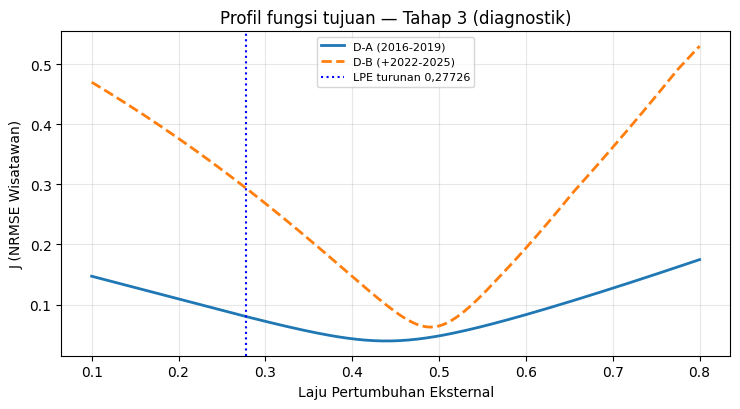

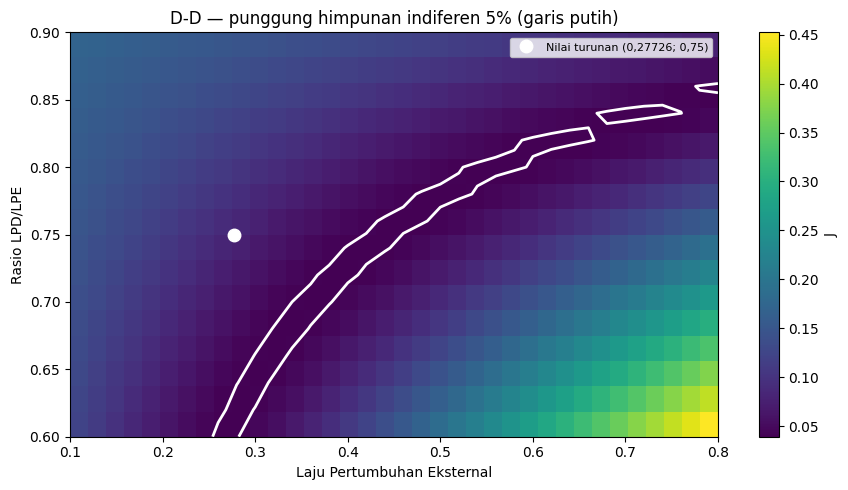

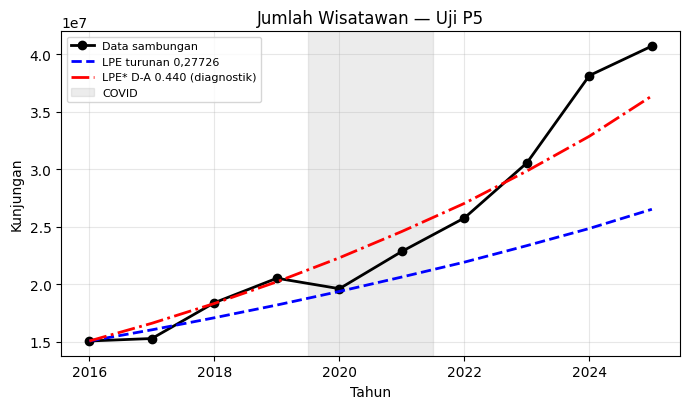

In [9]:
j_da = np.array([nrmse(cache[float(l)], DATA, M_DA) for l in LPE])
j_db = np.array([nrmse(cache[float(l)], DATA, M_DB) for l in LPE])
fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.plot(LPE, j_da, lw=2, label="D-A (2016-2019)")
ax.plot(LPE, j_db, lw=2, ls="--", label="D-B (+2022-2025)")
ax.axvline(LPE0, color="blue", ls=":", label="LPE turunan 0,27726")
ax.set_xlabel("Laju Pertumbuhan Eksternal"); ax.set_ylabel("J (NRMSE Wisatawan)")
ax.set_title("Profil fungsi tujuan — Tahap 3 (diagnostik)"); ax.grid(alpha=0.3); ax.legend(fontsize=8)
fig.tight_layout(); fig.savefig(FOLDER / "tahap3_profil_J.png", dpi=150); plt.show()

pv = dd.pivot(index="Rasio", columns="LPE", values="J")
fig, ax = plt.subplots(figsize=(9, 5))
im = ax.imshow(pv.values, origin="lower", aspect="auto", cmap="viridis",
               extent=[pv.columns.min(), pv.columns.max(), pv.index.min(), pv.index.max()])
ax.contour(pv.columns, pv.index, pv.values, levels=[1.05*jm], colors="white", linewidths=2)
ax.plot(LPE0, RASIO, "wo", ms=9, label="Nilai turunan (0,27726; 0,75)")
ax.set_xlabel("Laju Pertumbuhan Eksternal"); ax.set_ylabel("Rasio LPD/LPE")
ax.set_title("D-D — punggung himpunan indiferen 5% (garis putih)")
fig.colorbar(im, label="J"); ax.legend(fontsize=8)
fig.tight_layout(); fig.savefig(FOLDER / "tahap3_punggung_identifikasi.png", dpi=150); plt.show()

fig, ax = plt.subplots(figsize=(7, 4.2))
ax.plot(TAHUN, DATA, "ko-", lw=2, label="Data sambungan")
ax.plot(TAHUN, h0, "b--", lw=2, label="LPE turunan 0,27726")
ax.plot(TAHUN, run(float(ringkasan.iloc[0]["LPE*"])), "r-.", lw=2, label=f"LPE* D-A {ringkasan.iloc[0]['LPE*']:.3f} (diagnostik)")
ax.axvspan(2019.5, 2021.5, color="grey", alpha=0.15, label="COVID")
ax.set_xlabel("Tahun"); ax.set_ylabel("Kunjungan"); ax.grid(alpha=0.3); ax.legend(fontsize=8)
ax.set_title("Jumlah Wisatawan — Uji P5")
fig.tight_layout(); fig.savefig(FOLDER / "tahap3_wisatawan.png", dpi=150); plt.show()

## Simpan Excel

In [10]:
berkas = FOLDER / "hasil_diagnostik_tahap3.xlsx"
with pd.ExcelWriter(berkas) as w:
    ringkasan.round(6).to_excel(w, sheet_name="Ringkasan Diagnostik", index=False)
    banding.round(6).to_excel(w, sheet_name="Statistik", index=False)
    dd.round(6).to_excel(w, sheet_name="D-D Grid 2D", index=False)
    pert.round(4).to_excel(w, sheet_name="Pertumbuhan Tahunan", index=False)
    pd.DataFrame({"LPE":LPE, "J (D-A)":j_da, "J (D-B)":j_db}).round(6).to_excel(w, sheet_name="Profil J", index=False)
    pd.DataFrame({"Tahun":TAHUN, "Data sambungan":DATA,
                  "Simulasi (LPE turunan)":h0}).round(2).to_excel(w, sheet_name="Seri Wisatawan", index=False)
print("Tersimpan:", berkas)

Tersimpan: /content/drive/MyDrive/Skripsi_Citra/Pengujian Model Sistem Dinamis/[02] Uji Perilaku/Kalibrasi/hasil_diagnostik_tahap3.xlsx


## Angka untuk pencocokan

| Varian | LPE* | g* setara | J min | J pada LPE turunan |
|---|---|---|---|---|
| D-A | 0,440 | 11,00%/th | 0,03934 | 0,08019 |
| D-B | 0,490 | 12,25%/th | 0,06242 | 0,29419 |
| D-C faktor 2,22 | 0,410 | 10,25%/th | 0,05869 | 0,08269 |
| D-C faktor 2,38 | 0,470 | 11,75%/th | 0,03224 | 0,08713 |

**D-D:** minimum global LPE 0,720 dengan rasio 0,84; himpunan indiferen 5% mencakup 36 dari 576 titik,
membentang LPE 0,260–0,800 dan rasio 0,60–0,86 — punggung yang menunjukkan LPE dan LPD tidak teridentifikasi terpisah.

**Keputusan:** LPE 0,27726 dan LPD 0,207945 tetap final. Kelima kriteria penerimaan tidak terpenuhi.